# Project 1 — Mall Customer Segmentation (Hierarchical Clustering)

**Business problem:** A shopping mall wants to understand its customers better so its marketing
team can run targeted campaigns instead of one generic campaign for everyone.

We'll cluster customers using **Annual Income** and **Spending Score** with **Agglomerative
Hierarchical Clustering**, exactly the way a real data analyst would approach this.

> **Note on data:** This notebook generates a **synthetic dataset shaped like the well-known
> "Mall_Customers.csv"** dataset (CustomerID, Gender, Age, Annual Income (k$), Spending Score (1-100)),
> since this environment has no internet access to download the original file.
> **If you have the real `Mall_Customers.csv`**, just replace the "Generate synthetic data" cell
> with: `df = pd.read_csv('Mall_Customers.csv')` and the rest of the notebook works unchanged.


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 5)


## 2. Generate / Load the Dataset

In [2]:
# ---- Synthetic data generation (mimics Mall_Customers.csv structure & realistic patterns) ----
n = 200

# Simulate a few realistic customer segments so clustering has something meaningful to discover
segment_defs = [
    {'income_mean': 25, 'income_std': 6, 'spend_mean': 20, 'spend_std': 8, 'n': 40},   # low income, low spend
    {'income_mean': 25, 'income_std': 6, 'spend_mean': 80, 'spend_std': 8, 'n': 40},   # low income, high spend (impulsive)
    {'income_mean': 55, 'income_std': 8, 'spend_mean': 50, 'spend_std': 10, 'n': 40},  # mid income, mid spend
    {'income_mean': 85, 'income_std': 8, 'spend_mean': 20, 'spend_std': 8, 'n': 40},   # high income, low spend (careful)
    {'income_mean': 85, 'income_std': 8, 'spend_mean': 80, 'spend_std': 8, 'n': 40},   # high income, high spend (target VIPs)
]

rows = []
cid = 1
for seg in segment_defs:
    for _ in range(seg['n']):
        income = np.clip(np.random.normal(seg['income_mean'], seg['income_std']), 10, 140)
        spend = np.clip(np.random.normal(seg['spend_mean'], seg['spend_std']), 1, 100)
        age = np.random.randint(18, 70)
        gender = np.random.choice(['Male', 'Female'])
        rows.append([cid, gender, age, round(income, 1), round(spend, 1)])
        cid += 1

df = pd.DataFrame(rows, columns=['CustomerID', 'Gender', 'Age', 'AnnualIncome_k$', 'SpendingScore'])
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle
df.head()


,CustomerID,Gender,Age,AnnualIncome_k$,SpendingScore
0,96,Female,48,51.5,51.3
1,16,Male,31,19.6,29.5
2,31,Male,62,23.7,22.9
3,159,Male,28,88.0,9.0
4,129,Male,66,88.9,20.7


## 3. Exploratory Data Analysis (EDA)

In [3]:
df.describe()


,CustomerID,Age,AnnualIncome_k$,SpendingScore
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,44.915000,55.049500,50.617000
std,57.879185,15.296328,28.648478,27.682629
min,1.000000,18.000000,10.000000,4.700000
25%,50.750000,33.000000,26.375000,24.050000
50%,100.500000,47.500000,55.550000,49.400000
75%,150.250000,58.250000,82.375000,76.900000
max,200.000000,69.000000,109.600000,100.000000


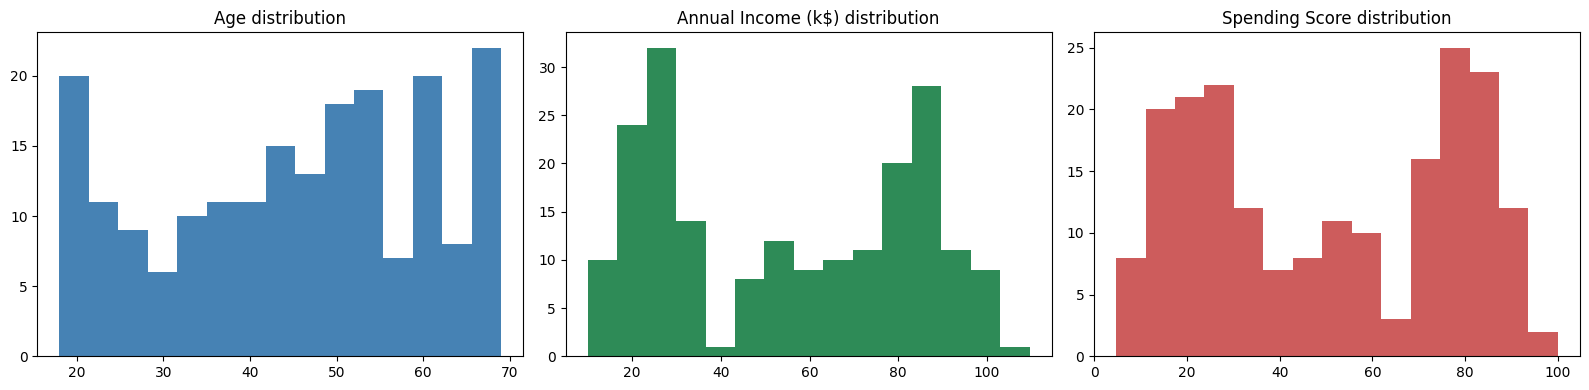

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(df['Age'], bins=15, color='steelblue')
axes[0].set_title('Age distribution')
axes[1].hist(df['AnnualIncome_k$'], bins=15, color='seagreen')
axes[1].set_title('Annual Income (k$) distribution')
axes[2].hist(df['SpendingScore'], bins=15, color='indianred')
axes[2].set_title('Spending Score distribution')
plt.tight_layout()
plt.show()


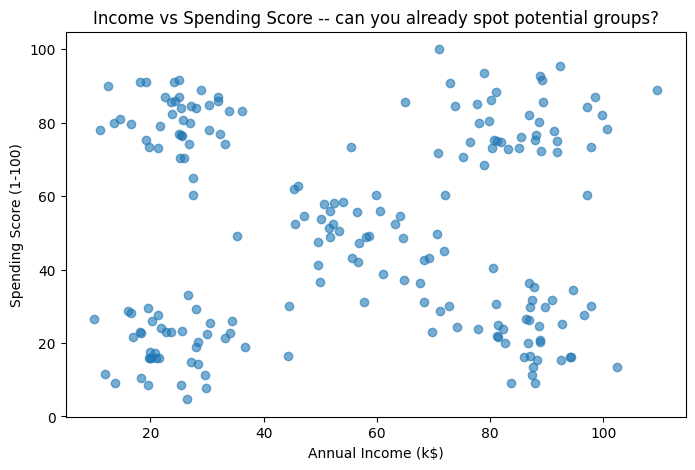

In [5]:
plt.scatter(df['AnnualIncome_k$'], df['SpendingScore'], alpha=0.6)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Income vs Spending Score -- can you already spot potential groups?')
plt.show()


## 4. Feature Selection & Scaling

We'll cluster on `AnnualIncome_k$` and `SpendingScore` — the two features that matter most for
this business question ("who spends how much relative to what they earn?").

As always with distance-based clustering: **scale first.**

In [6]:
features = df[['AnnualIncome_k$', 'SpendingScore']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
print("Scaled feature shape:", X_scaled.shape)


Scaled feature shape: (200, 2)


## 5. Build the Dendrogram

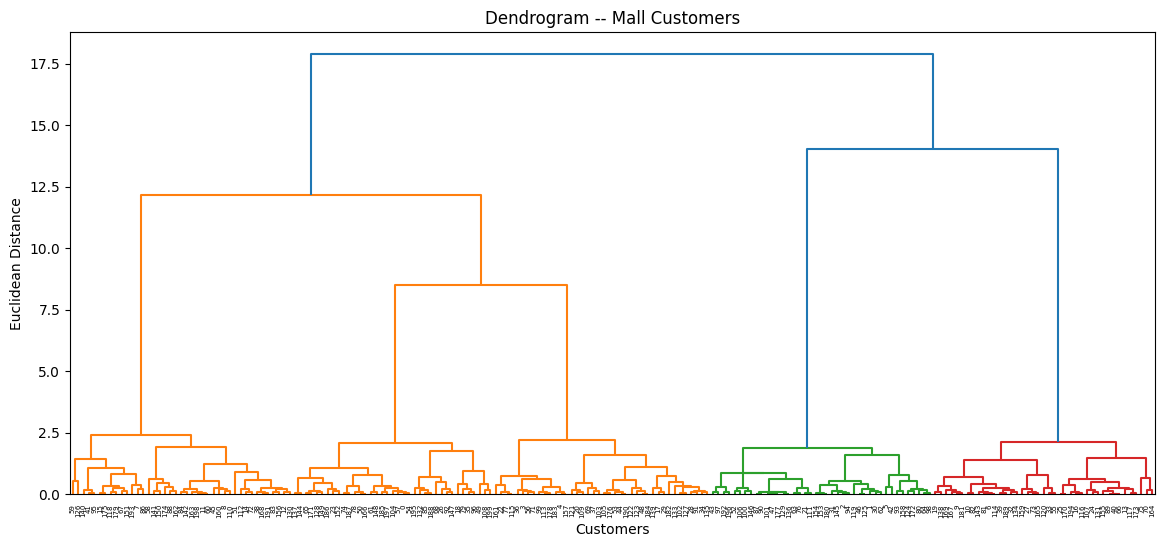

In [7]:
plt.figure(figsize=(14, 6))
plt.title('Dendrogram -- Mall Customers')
dendrogram(linkage(X_scaled, method='ward'))
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')
plt.show()


Apply the **longest vertical line, no horizontal line crossing it** trick from the notes.
For this dataset (5 realistic segments baked in), the dendrogram should clearly point toward
**around 5 clusters** — let's confirm programmatically too.

In [8]:
Z = linkage(X_scaled, method='ward')
merge_distances = Z[:, 2]
gaps = np.diff(merge_distances)
best_gap_index = np.argmax(gaps)
suggested_k = len(merge_distances) - best_gap_index
print(f"Suggested number of clusters: {suggested_k}")


Suggested number of clusters: 5


## 6. Apply Agglomerative Clustering

In [9]:
K = 5  # based on dendrogram + business knowledge (5 income/spending segments make sense for a mall)

hier_model = AgglomerativeClustering(n_clusters=K, metric='euclidean', linkage='ward')
df['Cluster'] = hier_model.fit_predict(X_scaled)

df.head()


,CustomerID,Gender,Age,AnnualIncome_k$,SpendingScore,Cluster
0,96,Female,48,51.5,51.3,4
1,16,Male,31,19.6,29.5,2
2,31,Male,62,23.7,22.9,2
3,159,Male,28,88.0,9.0,1
4,129,Male,66,88.9,20.7,1


## 7. Visualize the Segments

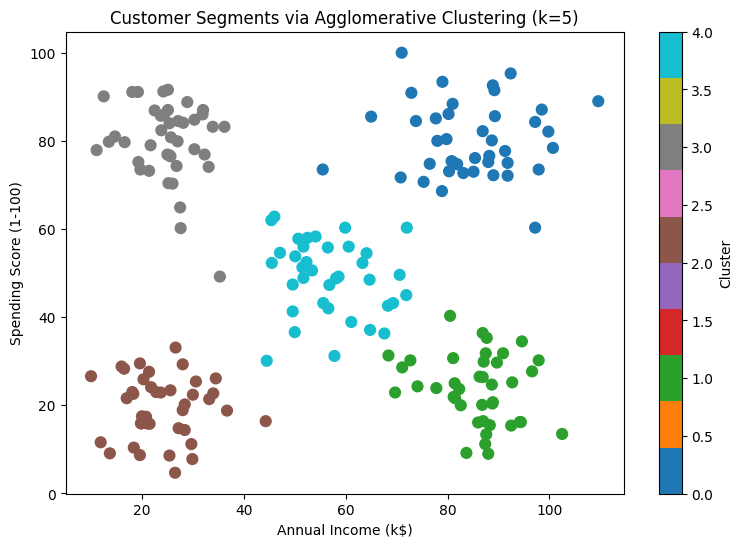

In [10]:
plt.figure(figsize=(9, 6))
scatter = plt.scatter(df['AnnualIncome_k$'], df['SpendingScore'], c=df['Cluster'], cmap='tab10', s=60)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title(f'Customer Segments via Agglomerative Clustering (k={K})')
plt.colorbar(scatter, label='Cluster')
plt.show()


In [11]:
sil = silhouette_score(X_scaled, df['Cluster'])
print(f"Silhouette Score: {sil:.3f}  (closer to 1 = well-separated clusters)")


Silhouette Score: 0.639  (closer to 1 = well-separated clusters)


## 8. Business Interpretation (the whole point of clustering!)

Let's summarize each cluster's average income/spending so the marketing team can name & target them.

In [12]:
cluster_summary = df.groupby('Cluster')[['AnnualIncome_k$', 'SpendingScore', 'Age']].mean().round(1)
cluster_summary['NumCustomers'] = df.groupby('Cluster').size()
cluster_summary


,AnnualIncome_k$,SpendingScore,Age,NumCustomers
Cluster,,,,
0,84.6,80.1,45.2,41
1,85.8,23.7,42.0,40
2,23.9,19.5,42.3,41
3,25.0,79.9,46.4,41
4,56.9,49.1,49.0,37


**Typical real-world naming of these segments (adjust based on YOUR actual cluster numbers above):**

- **Low income, low spend** → "Budget-conscious" — target with discounts/value bundles.
- **Low income, high spend** → "Impulsive spenders" — target with buy-now-pay-later / small-ticket promos.
- **Mid income, mid spend** → "Average / stable" — general campaigns, loyalty programs.
- **High income, low spend** → "Careful / untapped potential" — target with premium/personalized offers to unlock spend.
- **High income, high spend** → "VIP / High-value" — target with loyalty rewards, early access, premium experiences.

This is exactly how real retail/e-commerce companies decide where to spend their marketing budget.

## 9. Try It Yourself

- Add `Age` as a third clustering feature and see how segments change.
- Try `linkage='average'` or `'complete'` and compare dendrograms.
- Replace the synthetic data cell with the real `Mall_Customers.csv` if you have it, and re-run everything.
